In [265]:
import os
import random
import numpy as np
import tensorflow as tf
from glob import glob as gg
from matplotlib import pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import image_dataset_from_directory

In [229]:
model_path = "models/symbol_model.keras"

In [230]:
if not os.path.exists(model_path):
    raise Exception(f"File path {model_path} not found!")

In [231]:
model = load_model(model_path)

In [232]:
image_path = "pre_training"

In [233]:
pred_dataset = image_dataset_from_directory(image_path, image_size = (64, 64), batch_size = 64)

Found 181730 files belonging to 53 classes.


In [234]:
symbols = pred_dataset.class_names

In [235]:
symbol_dict = {}

symbol_dict = {idx: sym for idx, sym in enumerate(symbols)}

In [236]:
def process_image(image, label):
    image = tf.cast((image / 255), tf.float32)
    return image, label 

In [237]:
batch1 = pred_dataset.as_numpy_iterator().next()

In [238]:
print(batch1[0].shape)

(64, 64, 64, 3)


In [239]:
batch1_processed = process_image(batch1[0], batch1[1])

In [240]:
batch1_processed[1]

array([36, 17, 38,  1, 27, 15, 44,  9, 29, 13, 36, 45, 46,  5, 46, 10,  9,
       45,  4, 44, 20, 46,  5, 20,  9, 29, 40,  1, 17,  5, 11, 40,  4, 27,
        4, 22,  4, 40, 50,  0,  6, 52,  2, 38,  8, 50, 13, 22, 14, 36, 29,
       45,  0, 29, 24, 22,  4, 23, 47, 29, 50, 45, 39, 36], dtype=int32)

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

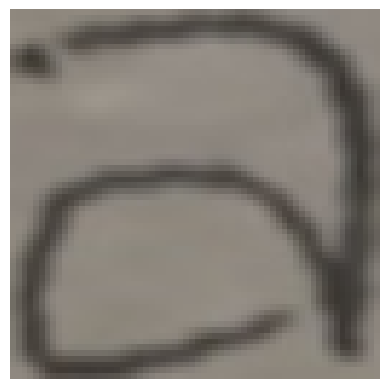

In [241]:
plt.imshow(batch1_processed[0][9])
plt.axis("off")

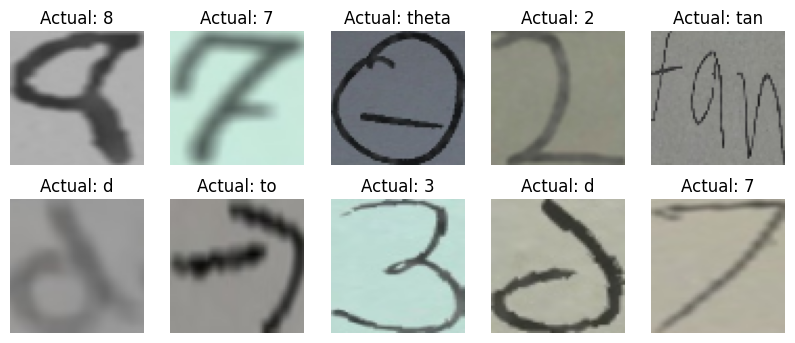

In [242]:
import random

fig, ax = plt.subplots(2, 5, figsize = (10, 4))

index = 0

num = random.randint(1, len(batch1_processed[0]) - 10)

for i in range(2):
    for j in range(5):
        ax[i][j].set_title(f"Actual: {symbol_dict[batch1_processed[1][num + index]]}")
        ax[i][j].imshow(batch1_processed[0][num + index])
        ax[i][j].axis("off")
        index += 1

In [243]:
batch2 = pred_dataset.as_numpy_iterator().next()

In [244]:
batch2_processed = process_image(batch2[0], batch2[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


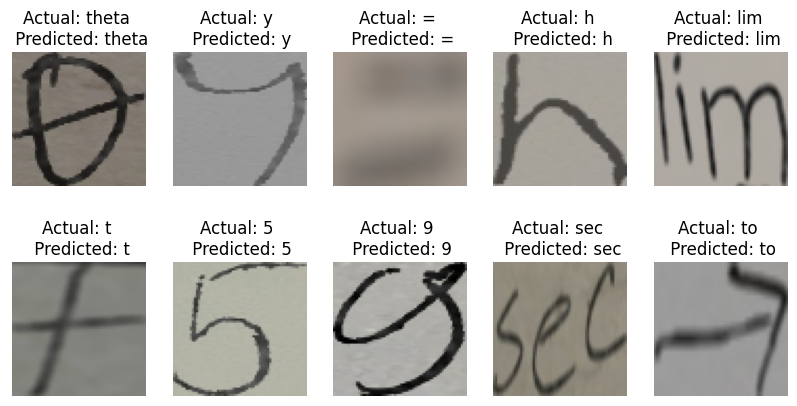

In [264]:
fig, ax = plt.subplots(2, 5, figsize = (10, 5))

index = 0

num = random.randint(1, len(batch2_processed[0]) - 10)

for i in range(2):
    for j in range(5):
        ax[i][j].set_title(f"Actual: {symbol_dict[batch2_processed[1][num + index]]} \n Predicted: { symbol_dict[np.argmax(model.predict(np.expand_dims(batch2_processed[0][num + index], 0)))] }")
        ax[i][j].imshow(batch2_processed[0][num + index])
        ax[i][j].axis("off")
        index += 1